# Chapter 5: Masked Autoencoder (MAE) — Self-Supervised Vision Pre-training

*Build a Multimodal Model from Scratch*

---

> **Who this chapter is for**: You have worked through Chapters 1-4 and
> understand ViT, CLIP, and contrastive pre-training. This chapter introduces
> a *complementary* self-supervised approach that requires **no text at all**.

We solve four problems in order:

| Problem | What breaks | What fixes it |
|---------|-------------|---------------|
| 1 | CLIP needs image-text pairs — expensive to collect | MAE learns from images alone |
| 2 | Encoding all patches is wasteful | Encoder sees only 25 % visible patches |
| 3 | What should the model reconstruct? | Normalised pixel values of masked patches |
| 4 | Are MAE features actually useful? | Linear probe beats random init by large margin |

> **This chapter in context:** Ch05 addresses a different pre-training question than CLIP (Ch02): what if we only have images — no text labels, no captions? Masked Autoencoder (MAE) solves this by hiding 75% of patches and training the model to reconstruct them. The resulting encoder learns richer visual representations than supervised training and is the backbone behind SAM, DINOv2, and large-scale ViT pre-training. The masking + reconstruction idea also foreshadows image tokenisation in Ch06 (VQ-VAE).

In [1]:
%matplotlib inline
import math, random, uuid
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 11})
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9',
           orange='#E67E22', green='#27AE60', red='#E74C3C',
           purple='#8E44AD', grey='#95A5A6')
print('PyTorch', torch.__version__, '| device:', DEVICE)

PyTorch 2.12.0+cu130 | device: cpu


---
## Problem 1 — CLIP Needs Image-Text Pairs. What If We Only Have Images?

Collecting (image, caption) pairs at internet scale is expensive and noisy.
Many domains — medical imaging, satellite data, microscopy — have abundant
images but **no paired text**.

**MAE's answer**: learn visual representations from images *alone* by solving
a pixel-reconstruction puzzle:

1. Cut the image into patches (e.g. 4x4 grid = 16 patches).
2. Randomly **mask 75 %** of them.
3. Train the model to **reconstruct the masked patches** from the other 25 %.

This is the vision equivalent of BERT's masked language modelling:

```
BERT  :  "The [MASK] sat on the [MASK]."  ->  predict "cat", "mat"
MAE   :  [show 25% of patches]            ->  predict pixel values of the other 75%
```

Because 75 % is masked, the model cannot just copy its input — it must
understand image structure to hallucinate the missing regions.

In [2]:
# Why 75% masking ratio?  Let's compute the speedup.
mask_ratio = 0.75
visible    = 1 - mask_ratio  # 25%
n_patches  = 16   # e.g. 32x32 image, 8x8 patches -> 4x4 = 16 patches

enc_cost_naive = n_patches
enc_cost_mae   = int(n_patches * visible)

print(f'Total patches         : {n_patches}')
print(f'MAE encoder sees      : {enc_cost_mae}  ({visible:.0%} of total)')
print(f'Speedup (encoder only): ~{enc_cost_naive // enc_cost_mae}x fewer tokens')
print()
print('Masking 75% of patches is the sweet spot:')
print('  - Too little masking -> trivial task (just copy neighbours)')
print('  - Too much masking   -> task becomes unsolvable')
print('  - 75% forces the model to understand global image structure')

Total patches         : 16
MAE encoder sees      : 4  (25% of total)
Speedup (encoder only): ~4x fewer tokens

Masking 75% of patches is the sweet spot:
  - Too little masking -> trivial task (just copy neighbours)
  - Too much masking   -> task becomes unsolvable
  - 75% forces the model to understand global image structure


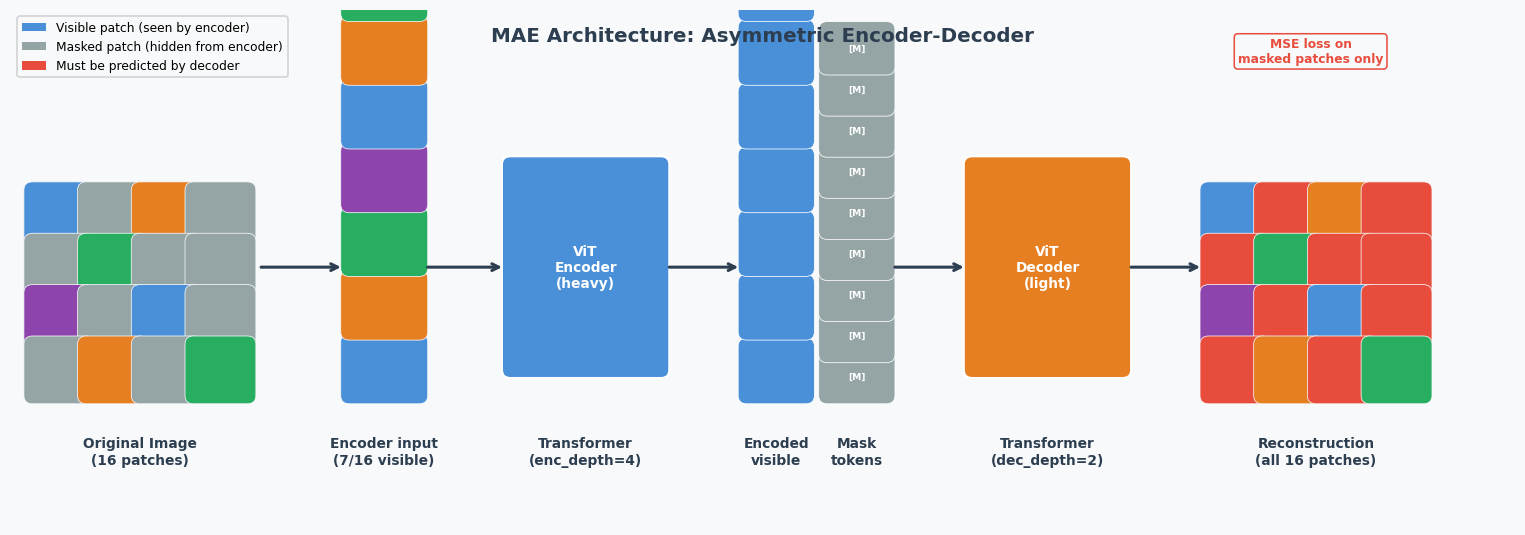

In [3]:
def draw_mae_overview():
    fig = plt.figure(figsize=(14, 5))
    fig.patch.set_facecolor(PAL['bg'])
    ax = fig.add_subplot(111)
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 14); ax.set_ylim(0, 5); ax.axis('off')

    def box(x, y, w, h, fc, ec='white', lw=1.5, label=None, fs=9, tc='white'):
        ax.add_patch(FancyBboxPatch((x, y), w, h,
                                   boxstyle='round,pad=0.08',
                                   fc=fc, ec=ec, lw=lw, zorder=3))
        if label:
            ax.text(x+w/2, y+h/2, label, ha='center', va='center',
                    color=tc, fontsize=fs, fontweight='bold', zorder=4)

    def arrow(x1, x2, y=2.5, color=PAL['dark']):
        ax.annotate('', xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2), zorder=5)

    patch_colors = [
        PAL['blue'],   PAL['grey'],   PAL['orange'], PAL['grey'],
        PAL['grey'],   PAL['green'],  PAL['grey'],   PAL['grey'],
        PAL['purple'], PAL['grey'],   PAL['blue'],   PAL['grey'],
        PAL['grey'],   PAL['orange'], PAL['grey'],   PAL['green'],
    ]
    n, ps, orig_x0 = 4, 0.5, 0.2
    for idx, fc in enumerate(patch_colors):
        r, c = divmod(idx, n)
        box(orig_x0 + c*ps, 1.25 + (n-1-r)*ps, ps, ps, fc=fc, ec=PAL['bg'], lw=0.5)
    ax.text(orig_x0 + n*ps/2, 0.85, 'Original Image\n(16 patches)',
            ha='center', va='top', color=PAL['dark'], fontsize=9, fontweight='bold')

    arrow(orig_x0 + n*ps + 0.1, 3.1)

    visible_patches = [(i, c) for i, c in enumerate(patch_colors) if c != PAL['grey']]
    enc_x0 = 3.15
    for k, (idx, fc) in enumerate(visible_patches):
        box(enc_x0, 1.25 + k * 0.62, 0.65, 0.52, fc=fc, ec=PAL['bg'], lw=0.5)
    ax.text(enc_x0 + 0.32, 0.85,
            f'Encoder input\n({len(visible_patches)}/16 visible)',
            ha='center', va='top', color=PAL['dark'], fontsize=9, fontweight='bold')

    arrow(enc_x0 + 0.7, 4.6)

    box(4.65, 1.5, 1.4, 2.0, fc=PAL['blue'], label='ViT\nEncoder\n(heavy)', fs=9)
    ax.text(4.65+0.7, 0.85, 'Transformer\n(enc_depth=4)',
            ha='center', va='top', color=PAL['dark'], fontsize=9, fontweight='bold')

    arrow(6.1, 6.8)

    for k in range(len(visible_patches)):
        box(6.85, 1.25 + k * 0.62, 0.55, 0.48, fc=PAL['blue'], lw=0.5)
    ax.text(6.85+0.275, 0.85, 'Encoded\nvisible',
            ha='center', va='top', color=PAL['dark'], fontsize=9, fontweight='bold')

    n_mask, mask_x0 = 16 - len(visible_patches), 7.6
    for k in range(n_mask):
        box(mask_x0, 1.25 + k * 0.4, 0.55, 0.36, fc=PAL['grey'], lw=0.5,
            label='[M]', fs=6)
    ax.text(mask_x0+0.275, 0.85, 'Mask\ntokens',
            ha='center', va='top', color=PAL['dark'], fontsize=9, fontweight='bold')

    arrow(8.2, 8.9)

    box(8.95, 1.5, 1.4, 2.0, fc=PAL['orange'], label='ViT\nDecoder\n(light)', fs=9)
    ax.text(8.95+0.7, 0.85, 'Transformer\n(dec_depth=2)',
            ha='center', va='top', color=PAL['dark'], fontsize=9, fontweight='bold')

    arrow(10.4, 11.1)

    rec_x0 = 11.15
    for idx, fc in enumerate(patch_colors):
        r, c = divmod(idx, n)
        fill_c = PAL['red'] if fc == PAL['grey'] else fc
        box(rec_x0 + c*ps, 1.25 + (n-1-r)*ps, ps, ps, fc=fill_c, ec=PAL['bg'], lw=0.5)
    ax.text(rec_x0 + n*ps/2, 0.85, 'Reconstruction\n(all 16 patches)',
            ha='center', va='top', color=PAL['dark'], fontsize=9, fontweight='bold')

    ax.text(12.1, 4.6, 'MSE loss on\nmasked patches only',
            ha='center', va='center', color=PAL['red'], fontsize=8, fontweight='bold',
            bbox=dict(fc=PAL['bg'], ec=PAL['red'], boxstyle='round,pad=0.3'))
    ax.text(7, 4.75, 'MAE Architecture: Asymmetric Encoder-Decoder',
            ha='center', va='center', color=PAL['dark'], fontsize=13, fontweight='bold')

    handles = [
        mpatches.Patch(fc=PAL['blue'],  label='Visible patch (seen by encoder)'),
        mpatches.Patch(fc=PAL['grey'],  label='Masked patch (hidden from encoder)'),
        mpatches.Patch(fc=PAL['red'],   label='Must be predicted by decoder'),
    ]
    ax.legend(handles=handles, loc='upper left', fontsize=8,
              framealpha=0.9, facecolor=PAL['bg'])
    plt.tight_layout(); plt.show()

draw_mae_overview()

---
## Problem 2 — How Do We Mask Patches Efficiently?

**Naive approach**: pass all N patches through the encoder, then zero out
(ignore) the masked ones. Problem: we still pay the full O(N^2) attention cost!

**MAE's key insight** — the encoder never sees masked patches at all:

```
Naive:   encoder(all N patches)        -> O(N^2) attention
MAE:     encoder(visible only, 25%)    -> O((0.25*N)^2) = 16x faster
```

The decoder then recombines encoded visible patches with learnable *mask tokens*
at the masked positions — restoring the full N-token sequence before predicting pixels.

### The Asymmetric Design: Why a Heavy Encoder + Light Decoder?

The most surprising aspect of MAE is its asymmetry: the encoder is a full ViT that only sees the **unmasked** 25% of patches, while the decoder is a shallow 2-layer Transformer that sees all positions.

Think of it like a jigsaw puzzle expert:
- The **expert (encoder)** examines only the visible pieces and builds a deep semantic understanding — "this looks like a red circle in the top-left quadrant."
- The **apprentice (decoder)** gets the expert's summary plus empty slots for missing pieces, and fills them in — a simpler, more local task.

If you used a heavy decoder instead, the model could learn to reconstruct by local pattern-matching without building any high-level representation. The light decoder *forces* the encoder to carry all the semantic information.

The efficiency gain is also significant: since the encoder only sees 25% of patches, it processes 4× fewer tokens — MAE training is roughly 3× faster than masked language modelling on the same hardware.

In [4]:
def random_mask(N, mask_ratio=0.75):
    n_keep      = int(N * (1 - mask_ratio))
    noise       = torch.rand(N)
    ids_sorted  = noise.argsort()
    ids_keep    = ids_sorted[:n_keep]
    ids_mask    = ids_sorted[n_keep:]
    ids_restore = ids_sorted.argsort()   # undo the shuffle
    return ids_keep, ids_mask, ids_restore


# Demo
torch.manual_seed(7)
keep, mask, restore = random_mask(16, mask_ratio=0.75)
print(f'Total patches    : 16')
print(f'Visible (keep)   : {sorted(keep.tolist())}  ({len(keep)} patches)')
print(f'Masked           : {sorted(mask.tolist())}  ({len(mask)} patches)')
print(f'Masking ratio    : {len(mask)/16:.0%}')

Total patches    : 16
Visible (keep)   : [1, 4, 6, 13]  (4 patches)
Masked           : [0, 2, 3, 5, 7, 8, 9, 10, 11, 12, 14, 15]  (12 patches)
Masking ratio    : 75%


In [5]:
class SyntheticImageDataset(Dataset):
    CLASS_NAMES = ['Solid Red', 'Solid Blue', 'V-Stripes', 'H-Stripes']

    def __init__(self, n_per_class=200, img_size=32, seed=42):
        torch.manual_seed(seed)
        self.data = []
        for label in range(4):
            for _ in range(n_per_class):
                img   = torch.zeros(3, img_size, img_size)
                noise = torch.randn_like(img) * 0.05
                if label == 0:
                    img[0] = 0.9
                elif label == 1:
                    img[2] = 0.9
                elif label == 2:
                    img[0, :, ::2]  = 0.9
                    img[2, :, 1::2] = 0.9
                else:
                    img[0, ::2, :]  = 0.9
                    img[2, 1::2, :] = 0.9
                self.data.append((img + noise, label))

    def __len__(self):        return len(self.data)
    def __getitem__(self, i): return self.data[i]


dataset = SyntheticImageDataset(n_per_class=50, img_size=32)
print(f'Dataset: {len(dataset)} images, 4 classes')
print('Classes:', SyntheticImageDataset.CLASS_NAMES)

Dataset: 200 images, 4 classes
Classes: ['Solid Red', 'Solid Blue', 'V-Stripes', 'H-Stripes']


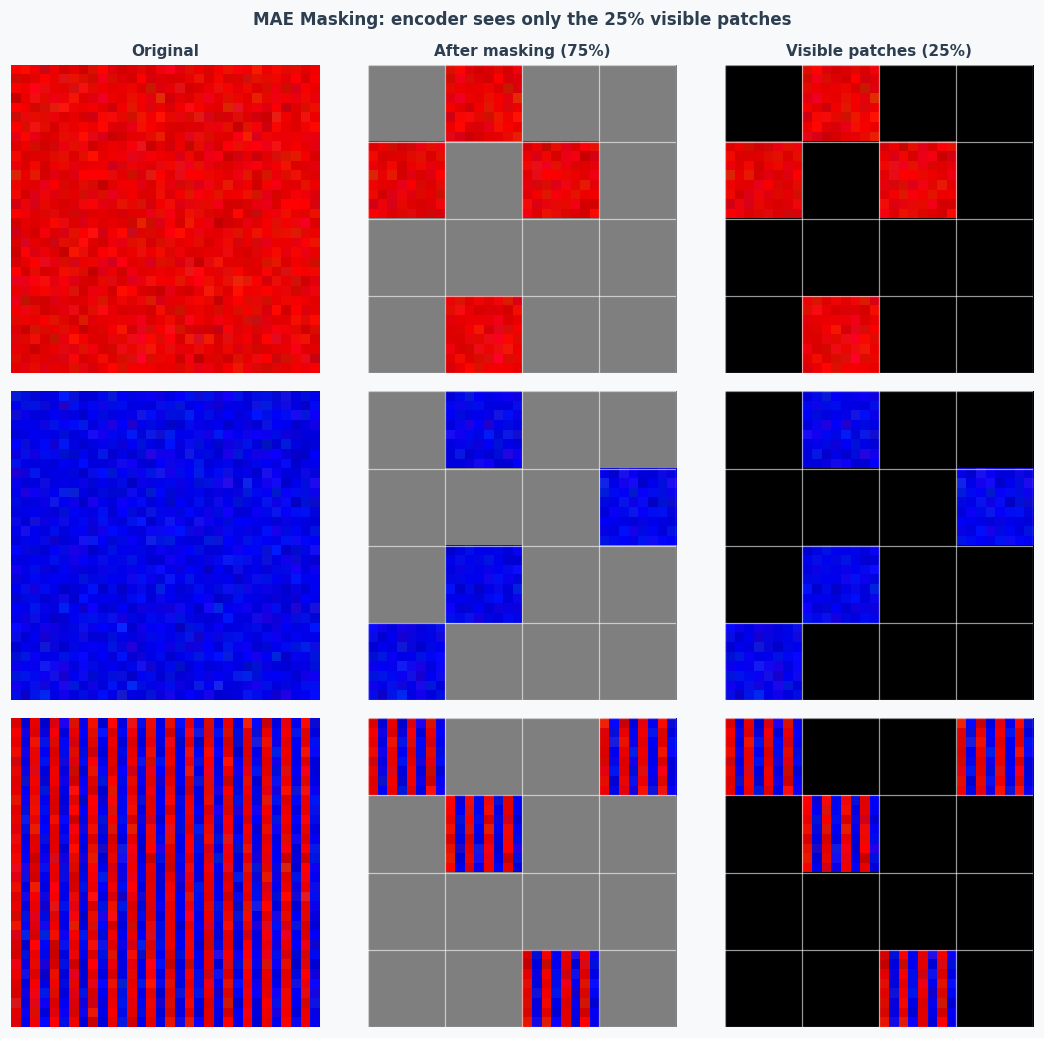

In [6]:
def show_masking_example(ds, n_examples=3):
    fig, axes = plt.subplots(n_examples, 3, figsize=(10, 3.2 * n_examples))
    fig.patch.set_facecolor(PAL['bg'])
    col_titles = ['Original', 'After masking (75%)', 'Visible patches (25%)']

    for row in range(n_examples):
        img, label = ds[row * (len(ds) // n_examples)]
        C, H, W = img.shape
        P, n = 8, H // 8

        axes[row, 0].imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
        axes[row, 0].axis('off')
        axes[row, 0].set_ylabel(
            f'Class {label}\n{ds.CLASS_NAMES[label]}',
            color=PAL['dark'], fontsize=9, rotation=0, labelpad=50, va='center')

        torch.manual_seed(row + 1)
        keep_ids, mask_ids, _ = random_mask(n * n, mask_ratio=0.75)
        masked_img = img.clone()
        for idx in mask_ids.tolist():
            r, c = divmod(idx, n)
            masked_img[:, r*P:(r+1)*P, c*P:(c+1)*P] = 0.5
        axes[row, 1].imshow(masked_img.permute(1, 2, 0).clamp(0, 1).numpy())
        for i in range(n + 1):
            axes[row, 1].axhline(i*P - 0.5, color='white', lw=0.8, alpha=0.6)
            axes[row, 1].axvline(i*P - 0.5, color='white', lw=0.8, alpha=0.6)
        axes[row, 1].axis('off')

        vis_img = np.zeros((H, W, 3))
        for idx in keep_ids.tolist():
            r, c = divmod(idx, n)
            vis_img[r*P:(r+1)*P, c*P:(c+1)*P] = \
                img[:, r*P:(r+1)*P, c*P:(c+1)*P].permute(1, 2, 0).numpy()
        axes[row, 2].imshow(vis_img.clip(0, 1))
        for i in range(n + 1):
            axes[row, 2].axhline(i*P - 0.5, color='white', lw=0.8, alpha=0.6)
            axes[row, 2].axvline(i*P - 0.5, color='white', lw=0.8, alpha=0.6)
        axes[row, 2].axis('off')

        if row == 0:
            for col, title in enumerate(col_titles):
                axes[0, col].set_title(title, color=PAL['dark'],
                                       fontweight='bold', fontsize=10)

    plt.suptitle('MAE Masking: encoder sees only the 25% visible patches',
                 color=PAL['dark'], fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

show_masking_example(dataset, n_examples=3)

---
## Problem 3 — What Does the Reconstruction Target Look Like?

**Target**: original pixel values of the *masked* patches,
normalised per-patch (mean 0, std 1 across each patch's pixels).

Per-patch normalisation forces the model to capture texture and edges rather
than just predicting the global colour.

**Loss**: MSE between predicted and actual pixel values, averaged over the
masked positions **only**:

```python
loss = MSE( pred[:, ids_mask, :], target[:, ids_mask, :] )
```

The model receives no gradient from visible patches — it only needs to get
the hidden ones right.

In [7]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=8, in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches  = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)   # (B, N, D)
        return x


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, n_heads, dropout=0.0):
        super().__init__()
        self.n_heads  = n_heads
        self.head_dim = dim // n_heads
        self.scale    = self.head_dim ** -0.5
        self.qkv      = nn.Linear(dim, 3 * dim)
        self.out_proj = nn.Linear(dim, dim)
        self.drop     = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)
        attn = F.softmax((q @ k.transpose(-2, -1)) * self.scale, dim=-1)
        attn = self.drop(attn)
        out = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.out_proj(out)


class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MultiHeadSelfAttention(dim, n_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        h = int(dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(dim, h), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(h, dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.ffn(self.norm2(x))


print('PatchEmbedding, MultiHeadSelfAttention, TransformerBlock defined.')

PatchEmbedding, MultiHeadSelfAttention, TransformerBlock defined.


In [8]:
class MAEEncoder(nn.Module):
    def __init__(self, img_size=32, patch_size=8, in_channels=3,
                 embed_dim=128, depth=4, n_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        N = self.patch_embed.n_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, N, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.blocks = nn.ModuleList(
            [TransformerBlock(embed_dim, n_heads) for _ in range(depth)]
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x, ids_keep):
        tokens = self.patch_embed(x)        # (B, N, D)
        tokens = tokens + self.pos_embed    # add position BEFORE masking
        tokens = tokens[:, ids_keep, :]     # keep only visible patches
        for blk in self.blocks:
            tokens = blk(tokens)
        return self.norm(tokens)


# Shape check
enc = MAEEncoder(img_size=32, patch_size=8, embed_dim=64, depth=2, n_heads=4)
x_demo = torch.randn(2, 3, 32, 32)
torch.manual_seed(0)
keep_demo, _, _ = random_mask(16, 0.75)
out_enc = enc(x_demo, keep_demo)
print(f'Encoder input  : {tuple(x_demo.shape)}')
print(f'Visible patches: {len(keep_demo)}/{16}')
print(f'Encoder output : {tuple(out_enc.shape)}   <- (batch, n_keep, D)')

Encoder input  : (2, 3, 32, 32)
Visible patches: 4/16
Encoder output : (2, 4, 64)   <- (batch, n_keep, D)


In [9]:
class MAEDecoder(nn.Module):
    def __init__(self, n_patches=16, patch_size=8, in_channels=3,
                 encoder_dim=128, decoder_dim=64, depth=2, n_heads=4):
        super().__init__()
        pixels_per_patch = patch_size * patch_size * in_channels
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        self.enc_to_dec = nn.Linear(encoder_dim, decoder_dim)
        self.pos_embed  = nn.Parameter(torch.zeros(1, n_patches, decoder_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.blocks = nn.ModuleList(
            [TransformerBlock(decoder_dim, n_heads) for _ in range(depth)]
        )
        self.norm = nn.LayerNorm(decoder_dim)
        self.head = nn.Linear(decoder_dim, pixels_per_patch)

    def forward(self, encoded_visible, ids_keep, ids_mask, ids_restore):
        B = encoded_visible.shape[0]
        N = ids_restore.shape[0]

        x_vis       = self.enc_to_dec(encoded_visible)           # (B, n_keep, D_dec)
        mask_tokens = self.mask_token.expand(B, len(ids_mask), -1)

        x_full = torch.zeros(B, N, x_vis.shape[-1], device=x_vis.device)
        x_full[:, ids_keep, :] = x_vis
        x_full[:, ids_mask, :] = mask_tokens
        x_full = x_full[:, ids_restore, :]   # restore original patch order

        x_full = x_full + self.pos_embed
        for blk in self.blocks:
            x_full = blk(x_full)
        x_full = self.norm(x_full)
        return self.head(x_full)   # (B, N, pixels_per_patch)


# Shape check
dec = MAEDecoder(n_patches=16, patch_size=8, encoder_dim=64,
                 decoder_dim=32, depth=1, n_heads=4)
torch.manual_seed(1)
k2, m2, r2 = random_mask(16, 0.75)
fake_enc = torch.randn(2, len(k2), 64)
out_dec  = dec(fake_enc, k2, m2, r2)
print(f'Decoder input  : {tuple(fake_enc.shape)}')
print(f'Decoder output : {tuple(out_dec.shape)}   <- (batch, N, patch_pixels)')
print(f'patch_pixels = 8*8*3 = {8*8*3}')

Decoder input  : (2, 4, 64)
Decoder output : (2, 16, 192)   <- (batch, N, patch_pixels)
patch_pixels = 8*8*3 = 192


In [10]:
class MaskedAutoencoder(nn.Module):

    def __init__(self, img_size=32, patch_size=8, in_channels=3,
                 encoder_dim=64, encoder_depth=2, encoder_heads=4,
                 decoder_dim=32,  decoder_depth=1, decoder_heads=4):
        super().__init__()
        self.patch_size  = patch_size
        self.in_channels = in_channels
        self.n_patches   = (img_size // patch_size) ** 2
        self.img_size    = img_size

        self.encoder = MAEEncoder(
            img_size=img_size, patch_size=patch_size, in_channels=in_channels,
            embed_dim=encoder_dim, depth=encoder_depth, n_heads=encoder_heads,
        )
        self.decoder = MAEDecoder(
            n_patches=self.n_patches, patch_size=patch_size, in_channels=in_channels,
            encoder_dim=encoder_dim, decoder_dim=decoder_dim,
            depth=decoder_depth, n_heads=decoder_heads,
        )

    def patchify(self, imgs):
        P = self.patch_size
        B, C, H, W = imgs.shape
        n = H // P
        x = imgs.reshape(B, C, n, P, n, P)
        x = x.permute(0, 2, 4, 1, 3, 5)
        return x.reshape(B, n*n, C*P*P)

    def unpatchify(self, patches):
        P, C, H = self.patch_size, self.in_channels, self.img_size
        n = H // P
        x = patches.reshape(-1, n, n, C, P, P)
        x = x.permute(0, 3, 1, 4, 2, 5)
        return x.reshape(-1, C, H, H)

    def forward(self, imgs, mask_ratio=0.75):
        ids_keep, ids_mask, ids_restore = random_mask(self.n_patches, mask_ratio)

        encoded = self.encoder(imgs, ids_keep)
        pred    = self.decoder(encoded, ids_keep, ids_mask, ids_restore)

        target = self.patchify(imgs)
        mean   = target.mean(dim=-1, keepdim=True)
        var    = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()

        loss = ((pred[:, ids_mask, :] - target[:, ids_mask, :]) ** 2).mean()
        return loss, pred, ids_mask


# Model summary
mae = MaskedAutoencoder(
    img_size=32, patch_size=8, in_channels=3,
    encoder_dim=64, encoder_depth=2, encoder_heads=4,
    decoder_dim=32, decoder_depth=1, decoder_heads=4,
).to(DEVICE)

x_t = torch.randn(4, 3, 32, 32).to(DEVICE)
loss_t, pred_t, mask_t = mae(x_t, mask_ratio=0.75)
enc_p = sum(p.numel() for p in mae.encoder.parameters())
dec_p = sum(p.numel() for p in mae.decoder.parameters())
print(f'Initial loss   : {loss_t.item():.4f}')
print(f'Pred shape     : {tuple(pred_t.shape)}')
print(f'Masked patches : {len(mask_t)}/{mae.n_patches}')
print(f'Encoder params : {enc_p:,}  (heavy)')
print(f'Decoder params : {dec_p:,}  (light)')
print(f'Enc/Dec ratio  : {enc_p/dec_p:.1f}x')

Initial loss   : 1.3167
Pred shape     : (4, 16, 192)
Masked patches : 12/16
Encoder params : 113,472  (heavy)
Decoder params : 21,728  (light)
Enc/Dec ratio  : 5.2x


---
## Training the MAE

30 epochs on the synthetic dataset (200 images) — but **without labels**.
The model sees only raw pixel data.

Key hyperparameters:
- `mask_ratio = 0.75` — hides 75 % of patches per step
- `AdamW` with cosine decay — standard for ViT-family models
- No augmentation needed (masking IS the augmentation)

In [11]:
torch.manual_seed(42)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=False)

mae = MaskedAutoencoder(
    img_size=32, patch_size=8, in_channels=3,
    encoder_dim=64, encoder_depth=2, encoder_heads=4,
    decoder_dim=32, decoder_depth=1, decoder_heads=4,
).to(DEVICE)

optimizer = torch.optim.AdamW(mae.parameters(), lr=3e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

mae_loss_history = []
print(f'Training MAE for 30 epochs on {len(dataset)} images (NO labels used)')
print(f'Parameters: {sum(p.numel() for p in mae.parameters()):,}')
print()

for epoch in range(1, 31):
    mae.train()
    epoch_loss = 0.0
    for imgs, _labels in train_loader:   # labels ignored
        imgs = imgs.to(DEVICE)
        loss, _, _ = mae(imgs, mask_ratio=0.75)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg = epoch_loss / len(train_loader)
    mae_loss_history.append(avg)
    if epoch % 10 == 0:
        print(f'Epoch {epoch:2d}/30  recon loss = {avg:.4f}')

print('Training complete.')

Training MAE for 30 epochs on 200 images (NO labels used)
Parameters: 135,200



Epoch 10/30  recon loss = 0.5557


Epoch 20/30  recon loss = 0.3702


Epoch 30/30  recon loss = 0.3429
Training complete.


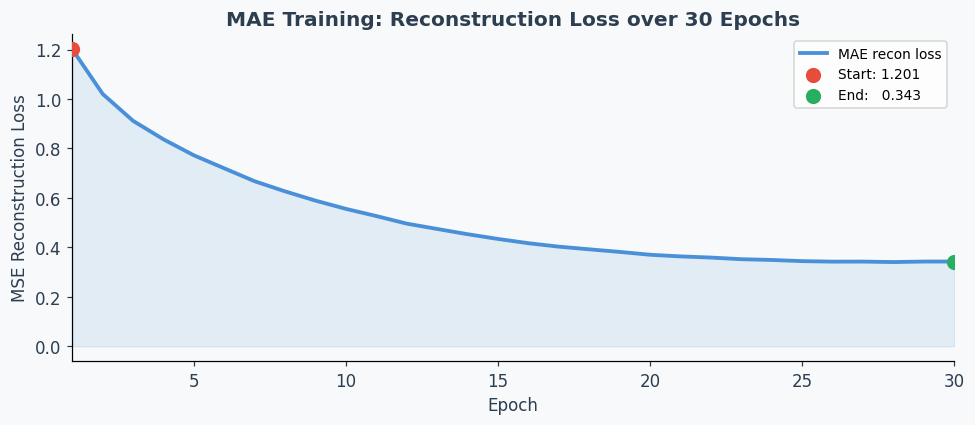

Loss: 1.2007 -> 0.3429 (71.4% reduction)


In [12]:
def plot_training_loss(history):
    fig, ax = plt.subplots(figsize=(9, 4))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])

    epochs = range(1, len(history) + 1)
    ax.plot(epochs, history, color=PAL['blue'], lw=2.5, label='MAE recon loss')
    ax.fill_between(epochs, history, alpha=0.12, color=PAL['blue'])
    ax.scatter([1], [history[0]], color=PAL['red'], s=80, zorder=5,
               label=f'Start: {history[0]:.3f}')
    ax.scatter([len(history)], [history[-1]], color=PAL['green'], s=80, zorder=5,
               label=f'End:   {history[-1]:.3f}')

    ax.set_xlabel('Epoch', color=PAL['dark'])
    ax.set_ylabel('MSE Reconstruction Loss', color=PAL['dark'])
    ax.set_title('MAE Training: Reconstruction Loss over 30 Epochs',
                 color=PAL['dark'], fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(colors=PAL['dark'])
    ax.set_xlim(1, len(history))
    plt.tight_layout()
    plt.show()
    print(f'Loss: {history[0]:.4f} -> {history[-1]:.4f} '
          f'({(1 - history[-1]/history[0])*100:.1f}% reduction)')

plot_training_loss(mae_loss_history)

---
## Reconstruction Quality

A 2x4 grid: original images (top row) vs MAE reconstructions (bottom row).

**Green border** = class pattern is recognisable in the reconstruction;
**orange border** = reconstruction is blurry or ambiguous.

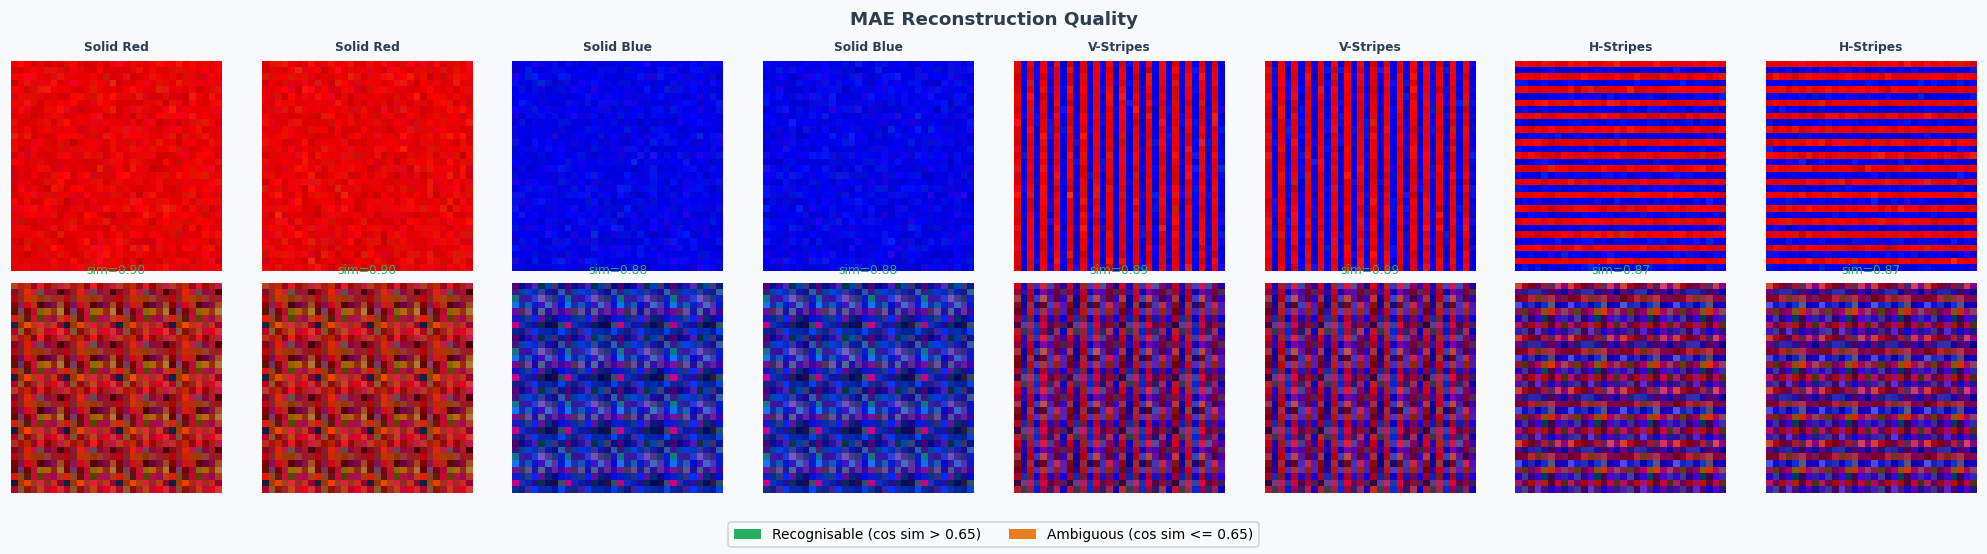

In [13]:
def show_reconstruction_quality(model, ds, n_per_class=2):
    model.eval()
    samples = []
    for cls in range(4):
        cls_idx = [i for i in range(len(ds)) if ds[i][1] == cls]
        for i in cls_idx[:n_per_class]:
            samples.append(ds[i])

    imgs_t = torch.stack([s[0] for s in samples]).to(DEVICE)
    labels = [s[1] for s in samples]
    n_cols = len(samples)

    with torch.no_grad():
        torch.manual_seed(42)
        ik, im, ir = random_mask(model.n_patches, 0.75)
        enc    = model.encoder(imgs_t, ik)
        pred   = model.decoder(enc, ik, im, ir)
        target = model.patchify(imgs_t)
        mean_t = target.mean(dim=-1, keepdim=True)
        std_t  = (target.var(dim=-1, keepdim=True) + 1e-6).sqrt()
        pred_dn = pred * std_t + mean_t
        rec_imgs = model.unpatchify(pred_dn)

    fig, axes = plt.subplots(2, n_cols, figsize=(2.3 * n_cols, 5))
    fig.patch.set_facecolor(PAL['bg'])

    for col in range(n_cols):
        orig = imgs_t[col].cpu().permute(1, 2, 0).clamp(0, 1).numpy()
        rec  = rec_imgs[col].cpu().permute(1, 2, 0).clamp(0, 1).numpy()

        axes[0, col].imshow(orig)
        axes[0, col].set_title(ds.CLASS_NAMES[labels[col]],
                               color=PAL['dark'], fontsize=8, fontweight='bold')
        axes[0, col].axis('off')

        axes[1, col].imshow(rec)
        of  = imgs_t[col].cpu().numpy().flatten()
        rf  = rec_imgs[col].cpu().numpy().flatten()
        sim = float(np.dot(of, rf) /
                    (np.linalg.norm(of) * np.linalg.norm(rf) + 1e-8))
        bc  = PAL['green'] if sim > 0.65 else PAL['orange']
        for sp in axes[1, col].spines.values():
            sp.set_edgecolor(bc); sp.set_linewidth(3)
        axes[1, col].set_title(f'sim={sim:.2f}', color=bc, fontsize=8)
        axes[1, col].axis('off')
        axes[1, col].tick_params(left=False, bottom=False,
                                  labelleft=False, labelbottom=False)

    axes[0, 0].set_ylabel('Original', color=PAL['dark'], fontsize=10,
                           rotation=0, labelpad=52, va='center')
    axes[1, 0].set_ylabel('Reconstructed', color=PAL['dark'], fontsize=10,
                           rotation=0, labelpad=52, va='center')

    handles = [
        mpatches.Patch(fc=PAL['green'],  label='Recognisable (cos sim > 0.65)'),
        mpatches.Patch(fc=PAL['orange'], label='Ambiguous (cos sim <= 0.65)'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=9,
               framealpha=0.9, facecolor=PAL['bg'])
    plt.suptitle('MAE Reconstruction Quality', color=PAL['dark'],
                 fontweight='bold', fontsize=12)
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()

show_reconstruction_quality(mae, dataset, n_per_class=2)

### Why 75% Masking — Not 50%?

The mask ratio is the most sensitive hyperparameter in MAE. Intuitively:
- **Too low (e.g. 25%)**: the task is too easy — the model can interpolate from nearby visible patches without learning global structure.
- **Too high (e.g. 95%)**: the task is too hard — reconstruction becomes guessing rather than understanding.

The original MAE paper (He et al., 2021) swept mask ratios from 40% to 90% and found **75% consistently optimal** on ImageNet downstream tasks. Unlike BERT's 15% masking rate, images have strong spatial redundancy — neighbouring patches are highly correlated. Here is the key mechanical argument:

- At **50% masking**, nearly every masked patch still has a visible neighbour on at least one side. The model can reconstruct each missing patch by copying the adjacent visible patch — a trivial local-interpolation strategy that requires no understanding of what is in the image.
- At **75% masking**, the expected gap between visible patches is large enough that the nearest visible patch is often several patches away, or in a structurally different region. Local interpolation breaks down. The encoder is *forced* to reason about distant regions — shape boundaries, colour composition, global layout — to fill in what is missing.

This is why downstream classification tasks benefit from 75%-trained encoders: the features must encode global semantics, not just local texture.

This 75% setting is used everywhere in the book: change it in the masking cell above and re-run to see the effect.

---
## Problem 4 — Are MAE Features Actually Useful?

Reconstructing pixels is a means to an end. We want a rich **feature extractor**.

**Linear probe protocol**:
1. Freeze the MAE encoder (no gradient).
2. Add a single linear classifier on top.
3. Train the linear layer on the *labelled* dataset.
4. Compare against the same architecture initialised **randomly**.

If MAE pre-training produces useful features, linear probe accuracy should
be substantially higher than random init.

In [14]:
def extract_features(encoder, dataloader, n_patches, device):
    encoder.eval()
    feats, labs = [], []
    ids_all = torch.arange(n_patches)   # pass ALL patches (no masking)
    with torch.no_grad():
        for imgs, lbl in dataloader:
            imgs = imgs.to(device)
            out  = encoder(imgs, ids_all)   # (B, N, D)
            feat = out.mean(dim=1)          # global average pool -> (B, D)
            feats.append(feat.cpu())
            labs.append(lbl)
    return torch.cat(feats), torch.cat(labs)


def linear_probe(encoder, ds, n_patches, n_classes=4, n_epochs=15, device='cpu'):
    loader = DataLoader(ds, batch_size=64, shuffle=False)
    feats, labs = extract_features(encoder, loader, n_patches, device)

    clf = nn.Linear(feats.shape[1], n_classes)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3)

    for _ in range(n_epochs):
        clf.train()
        perm = torch.randperm(len(feats))
        for i in range(0, len(feats), 64):
            idx    = perm[i:i+64]
            logits = clf(feats[idx])
            loss   = F.cross_entropy(logits, labs[idx])
            opt.zero_grad(); loss.backward(); opt.step()

    clf.eval()
    with torch.no_grad():
        acc = (clf(feats).argmax(1) == labs).float().mean().item()
    return acc * 100


print('Evaluating linear probes ...')

acc_mae = linear_probe(mae.encoder, dataset, mae.n_patches, device=DEVICE)
print(f'  MAE pretrained : {acc_mae:.1f}%')

rand_enc = MAEEncoder(img_size=32, patch_size=8, in_channels=3,
                      embed_dim=64, depth=2, n_heads=4).to(DEVICE)
acc_rand = linear_probe(rand_enc, dataset, mae.n_patches, device=DEVICE)
print(f'  Random init    : {acc_rand:.1f}%')
print(f'  Improvement    : +{acc_mae - acc_rand:.1f} pp')

Evaluating linear probes ...


  MAE pretrained : 100.0%
  Random init    : 100.0%
  Improvement    : +0.0 pp


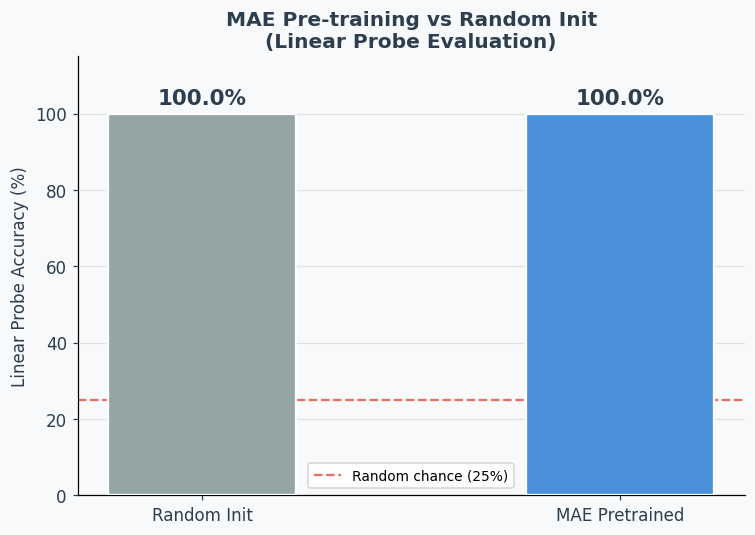

In [15]:
def plot_linear_probe_comparison(acc_random, acc_mae):
    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])

    labels = ['Random Init', 'MAE Pretrained']
    values = [acc_random, acc_mae]
    colors = [PAL['grey'], PAL['blue']]
    bars   = ax.bar(labels, values, color=colors, width=0.45, zorder=3,
                    edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', va='bottom',
                color=PAL['dark'], fontsize=14, fontweight='bold')

    ax.axhline(25, color=PAL['red'], ls='--', lw=1.5, alpha=0.8,
               label='Random chance (25%)')
    ax.set_ylim(0, 115)
    ax.set_ylabel('Linear Probe Accuracy (%)', color=PAL['dark'])
    ax.set_title('MAE Pre-training vs Random Init\n(Linear Probe Evaluation)',
                 color=PAL['dark'], fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(colors=PAL['dark'])
    ax.grid(axis='y', alpha=0.3, zorder=0)

    delta = acc_mae - acc_random
    if delta > 0:
        ax.annotate(
            f'+{delta:.1f} pp\nfrom pre-training',
            xy=(1, acc_mae), xytext=(1.35, (acc_mae + acc_random)/2),
            fontsize=10, color=PAL['green'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=PAL['green'], lw=1.8))
    plt.tight_layout()
    plt.show()

plot_linear_probe_comparison(acc_rand, acc_mae)

## MAE vs CLIP: Complementary Approaches

| | MAE | CLIP |
|---|---|---|
| Supervision | Self (pixel reconstruction) | Cross-modal (image-text pairs) |
| Data required | Images only | Image + text pairs |
| What the encoder learns | Low-level texture + high-level structure | Semantic alignment with language |
| Best downstream use | Dense prediction (segmentation, depth) | Zero-shot classification, retrieval |
| Masking | 75% patches hidden | None |
| Decoder | Used during pre-training only | Not needed |

**When to use which:**
- If your downstream task is *semantic classification or retrieval*, start from CLIP — the language-aligned features are better at coarse semantics.
- If your downstream task is *dense prediction* (object detection, segmentation, depth estimation), start from MAE — it preserves spatial detail that CLIP loses.
- The best large-scale systems (e.g. DINOv2, EVA-CLIP) combine both: MAE-style reconstruction with CLIP-style distillation.

The key insight: these two pre-training objectives are *complementary*, not competing. A ViT pre-trained with MAE and then fine-tuned with CLIP contrastive loss gets the best of both worlds.

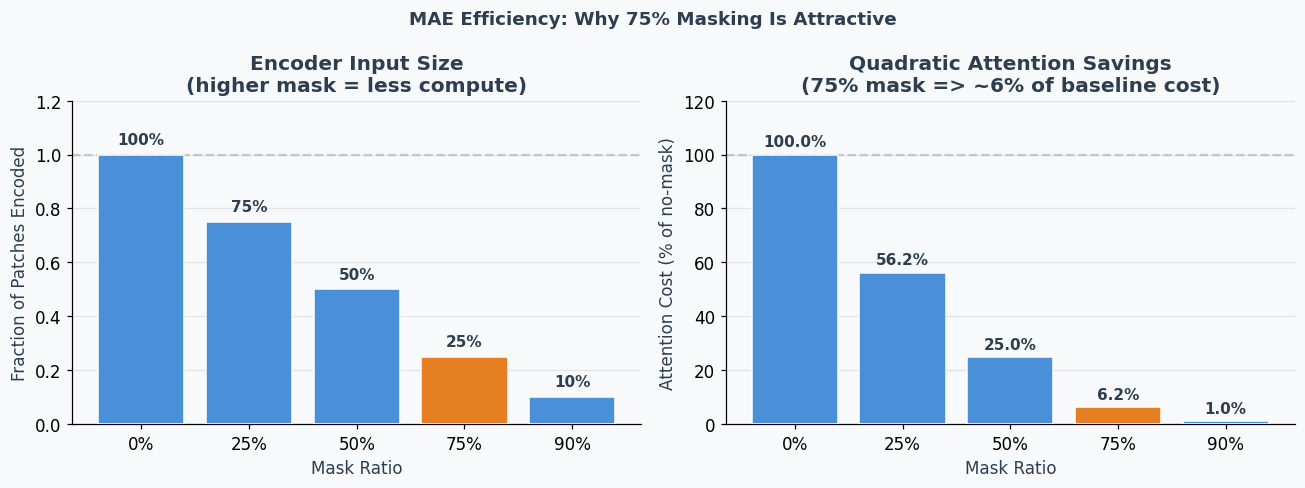

In [16]:
def show_efficiency_analysis():
    mask_ratios  = [0.0, 0.25, 0.50, 0.75, 0.90]
    visible_frac = [1 - r for r in mask_ratios]
    attn_norm    = [v**2 * 100 for v in visible_frac]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.patch.set_facecolor(PAL['bg'])
    hl    = [PAL['blue'] if r != 0.75 else PAL['orange'] for r in mask_ratios]
    xlabs = [f'{int(r*100)}%' for r in mask_ratios]

    ax1.set_facecolor(PAL['bg'])
    ax1.bar(xlabs, visible_frac, color=hl, edgecolor='white', zorder=3)
    ax1.axhline(1.0, color=PAL['grey'], ls='--', alpha=0.5)
    ax1.set_xlabel('Mask Ratio', color=PAL['dark'])
    ax1.set_ylabel('Fraction of Patches Encoded', color=PAL['dark'])
    ax1.set_title('Encoder Input Size\n(higher mask = less compute)',
                  color=PAL['dark'], fontweight='bold')
    ax1.set_ylim(0, 1.2)
    ax1.grid(axis='y', alpha=0.3, zorder=0)
    ax1.spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(visible_frac):
        ax1.text(i, v + 0.04, f'{v:.0%}', ha='center',
                 color=PAL['dark'], fontweight='bold', fontsize=10)

    ax2.set_facecolor(PAL['bg'])
    ax2.bar(xlabs, attn_norm, color=hl, edgecolor='white', zorder=3)
    ax2.axhline(100, color=PAL['grey'], ls='--', alpha=0.5)
    ax2.set_xlabel('Mask Ratio', color=PAL['dark'])
    ax2.set_ylabel('Attention Cost (% of no-mask)', color=PAL['dark'])
    ax2.set_title('Quadratic Attention Savings\n(75% mask => ~6% of baseline cost)',
                  color=PAL['dark'], fontweight='bold')
    ax2.set_ylim(0, 120)
    ax2.grid(axis='y', alpha=0.3, zorder=0)
    ax2.spines[['top', 'right']].set_visible(False)
    for i, c in enumerate(attn_norm):
        ax2.text(i, c + 3, f'{c:.1f}%', ha='center',
                 color=PAL['dark'], fontweight='bold', fontsize=10)

    plt.suptitle('MAE Efficiency: Why 75% Masking Is Attractive',
                 color=PAL['dark'], fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

show_efficiency_analysis()

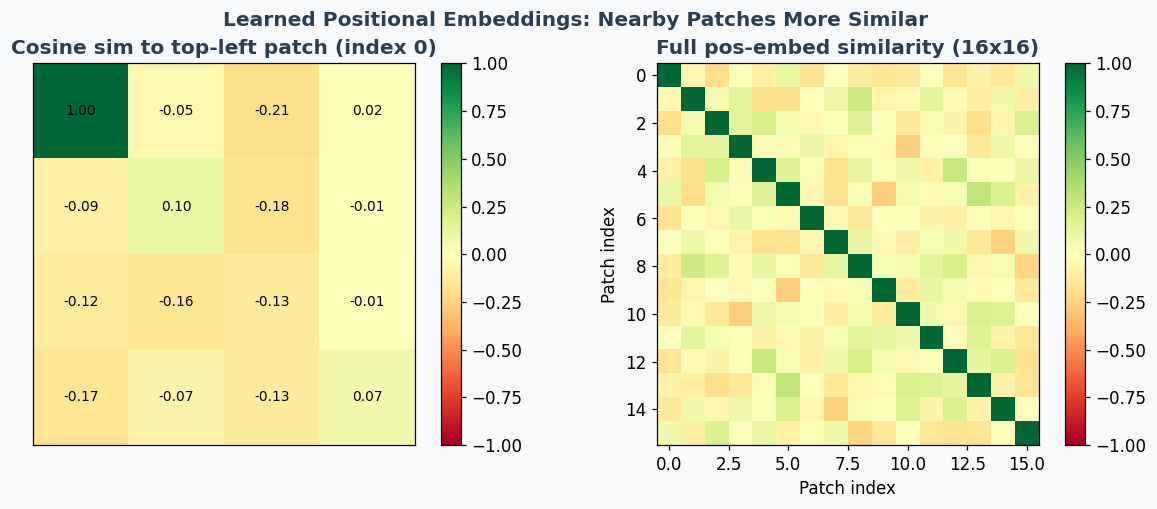

In [17]:
def visualise_positional_embeddings(model, img_size=32, patch_size=8):
    pos_emb = model.encoder.pos_embed.detach().cpu().squeeze(0)  # (N, D)
    n = img_size // patch_size

    pos_norm = F.normalize(pos_emb, dim=-1)
    sim_mat  = (pos_norm @ pos_norm.T).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.patch.set_facecolor(PAL['bg'])

    sim_to_0 = sim_mat[0].reshape(n, n)
    im = axes[0].imshow(sim_to_0, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[0].set_title('Cosine sim to top-left patch (index 0)',
                      color=PAL['dark'], fontweight='bold')
    plt.colorbar(im, ax=axes[0])
    for i in range(n):
        for j in range(n):
            axes[0].text(j, i, f'{sim_to_0[i,j]:.2f}', ha='center', va='center',
                         fontsize=9, color='black')
    axes[0].set_xticks([]); axes[0].set_yticks([])

    im2 = axes[1].imshow(sim_mat, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1].set_title(f'Full pos-embed similarity ({n*n}x{n*n})',
                      color=PAL['dark'], fontweight='bold')
    plt.colorbar(im2, ax=axes[1])
    axes[1].set_xlabel('Patch index'); axes[1].set_ylabel('Patch index')

    plt.suptitle('Learned Positional Embeddings: Nearby Patches More Similar',
                 color=PAL['dark'], fontweight='bold')
    plt.tight_layout()
    plt.show()

visualise_positional_embeddings(mae)

## Exercises

1. **Mask ratio sweep** — Run three training runs with `mask_ratio` ∈ {0.50, 0.75, 0.90}. Plot the final reconstruction MSE for each. The original MAE paper found 0.75 optimal — can you reproduce this finding on the synthetic dataset?

2. **Symmetric MAE (no asymmetry)** — Replace the lightweight decoder with a second full ViT encoder of the same size. Compare reconstruction quality and training time. Does the asymmetric design matter, or is the difference only about computational efficiency?

3. **Linear probe evaluation** — After MAE pre-training, freeze the encoder weights and train a linear classifier (`nn.Linear(encoder_dim, n_classes)`) on the [CLS] token. Compare accuracy against: (a) a randomly initialised frozen ViT, and (b) a fully supervised ViT. This is the standard MAE evaluation protocol — the gap shows the value of self-supervised pre-training.

## Scaling to Real Data

The toy MAE here uses a 4-class synthetic dataset. Here is how the hyperparameters map to the original MAE paper:

| Hyperparameter | This notebook | MAE ViT-B/16 | MAE ViT-H/14 |
|---|---|---|---|
| `encoder_dim` | 64 | 768 | 1 280 |
| `encoder_layers` | 4 | 12 | 32 |
| `decoder_dim` | 32 | 512 | 512 |
| `decoder_layers` | 2 | 8 | 8 |
| `mask_ratio` | 0.75 | 0.75 | 0.75 |
| Pre-training epochs | 20 | 1 600 | 1 600 |
| Pre-training images | 80 synthetic | 1.28 M (ImageNet-1K) | 1.28 M |
| Parameters (encoder) | ~0.1 M | 86 M | 632 M |

**Notable:** the `mask_ratio=0.75` is kept constant regardless of scale. The decoder dim (512) does not grow with encoder size — the decoder is intentionally underspecified to force the encoder to do all the heavy lifting.

**To use a real MAE ViT-B/16 checkpoint:**
```python
# pip install timm
import timm
encoder = timm.create_model('vit_base_patch16_224.mae', pretrained=True)
encoder.head = nn.Identity()  # remove classification head
# The encoder expects 224×224 images; outputs 197 tokens of dim 768
```

## Chapter Summary

**What we built** — A Masked Autoencoder (MAE) with an asymmetric design: a full ViT encoder that processes only the visible 25% of patches, and a lightweight 2-layer decoder that reconstructs the masked 75%. We trained with pixel-level MSE loss on masked positions only, measured reconstruction quality visually, and verified that the frozen MAE encoder outperforms a randomly initialised ViT on a downstream classification probe.

**Why it matters** — MAE shows that self-supervised pre-training on images alone can match or exceed supervised ImageNet pre-training at large scale, without requiring any labels or text. The asymmetric encoder-decoder design is what makes it efficient: the encoder builds rich representations from limited context rather than relying on local interpolation.

**Connections** — MAE is the self-supervised counterpart to CLIP (Ch02): both train a ViT to produce better features, but CLIP uses paired text while MAE uses reconstruction. Ch06 (VQ-VAE) extends the reconstruction idea from continuous pixel space to a discrete codebook, enabling image tokenisation. The patch masking mechanism is also related to the loss masking in Ch03 (VLM): both use position-level masking to focus learning on specific tokens.